In [123]:
# Get and Understand the Dataset

In [124]:
import numpy as np
import pandas as pd
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("ML environment is ready!")

NumPy: 2.5.2
Pandas: 3.0.5
Scikit-learn: 1.9.0
ML environment is ready!


In [125]:
import pandas as pd
import numpy as np

In [126]:
df = pd.read_csv("../data/PhiUSIIL_Phishing_URL_Dataset.csv")

In [127]:
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [128]:
df.shape

(235795, 56)

In [129]:
df.columns.tolist()

['FILENAME',
 'URL',
 'URLLength',
 'Domain',
 'DomainLength',
 'IsDomainIP',
 'TLD',
 'URLSimilarityIndex',
 'CharContinuationRate',
 'TLDLegitimateProb',
 'URLCharProb',
 'TLDLength',
 'NoOfSubDomain',
 'HasObfuscation',
 'NoOfObfuscatedChar',
 'ObfuscationRatio',
 'NoOfLettersInURL',
 'LetterRatioInURL',
 'NoOfDegitsInURL',
 'DegitRatioInURL',
 'NoOfEqualsInURL',
 'NoOfQMarkInURL',
 'NoOfAmpersandInURL',
 'NoOfOtherSpecialCharsInURL',
 'SpacialCharRatioInURL',
 'IsHTTPS',
 'LineOfCode',
 'LargestLineLength',
 'HasTitle',
 'Title',
 'DomainTitleMatchScore',
 'URLTitleMatchScore',
 'HasFavicon',
 'Robots',
 'IsResponsive',
 'NoOfURLRedirect',
 'NoOfSelfRedirect',
 'HasDescription',
 'NoOfPopup',
 'NoOfiFrame',
 'HasExternalFormSubmit',
 'HasSocialNet',
 'HasSubmitButton',
 'HasHiddenFields',
 'HasPasswordField',
 'Bank',
 'Pay',
 'Crypto',
 'HasCopyrightInfo',
 'NoOfImage',
 'NoOfCSS',
 'NoOfJS',
 'NoOfSelfRef',
 'NoOfEmptyRef',
 'NoOfExternalRef',
 'label']

In [130]:
df["label"].value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation           

In [132]:
df.isnull().sum().sum()

np.int64(0)

In [133]:
df["URL"].duplicated().sum()

np.int64(425)

In [134]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [135]:
df["label"].value_counts(normalize=True) * 100

label
1    57.189508
0    42.810492
Name: proportion, dtype: float64

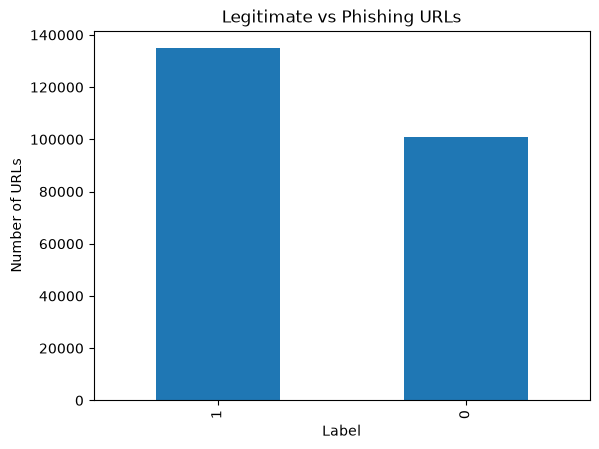

In [136]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Legitimate vs Phishing URLs")
plt.xlabel("Label")
plt.ylabel("Number of URLs")
plt.show()

In [137]:
# Data Cleaning + EDA

In [138]:
df.columns.tolist()

['FILENAME',
 'URL',
 'URLLength',
 'Domain',
 'DomainLength',
 'IsDomainIP',
 'TLD',
 'URLSimilarityIndex',
 'CharContinuationRate',
 'TLDLegitimateProb',
 'URLCharProb',
 'TLDLength',
 'NoOfSubDomain',
 'HasObfuscation',
 'NoOfObfuscatedChar',
 'ObfuscationRatio',
 'NoOfLettersInURL',
 'LetterRatioInURL',
 'NoOfDegitsInURL',
 'DegitRatioInURL',
 'NoOfEqualsInURL',
 'NoOfQMarkInURL',
 'NoOfAmpersandInURL',
 'NoOfOtherSpecialCharsInURL',
 'SpacialCharRatioInURL',
 'IsHTTPS',
 'LineOfCode',
 'LargestLineLength',
 'HasTitle',
 'Title',
 'DomainTitleMatchScore',
 'URLTitleMatchScore',
 'HasFavicon',
 'Robots',
 'IsResponsive',
 'NoOfURLRedirect',
 'NoOfSelfRedirect',
 'HasDescription',
 'NoOfPopup',
 'NoOfiFrame',
 'HasExternalFormSubmit',
 'HasSocialNet',
 'HasSubmitButton',
 'HasHiddenFields',
 'HasPasswordField',
 'Bank',
 'Pay',
 'Crypto',
 'HasCopyrightInfo',
 'NoOfImage',
 'NoOfCSS',
 'NoOfJS',
 'NoOfSelfRef',
 'NoOfEmptyRef',
 'NoOfExternalRef',
 'label']

In [139]:
df.dtypes

FILENAME                          str
URL                               str
URLLength                       int64
Domain                            str
DomainLength                    int64
IsDomainIP                      int64
TLD                               str
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
LineOfCode  

In [140]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:", len(numeric_columns))
print("Categorical columns:", len(categorical_columns))

print("\nNumerical:")
print(numeric_columns)

print("\nCategorical:")
print(categorical_columns)

Numerical columns: 51
Categorical columns: 5

Numerical:
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']

Categorical:
['FILENAME', 'URL', 'Domain', 'TLD', 'Title']


C:\Users\premk\AppData\Local\Temp\ipykernel_20332\3457422065.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


In [141]:
df["FILENAME"].value_counts()

FILENAME
521848.txt     1
31372.txt      1
597387.txt     1
554095.txt     1
151578.txt     1
              ..
660997.txt     1
77185.txt      1
622132.txt     1
7503962.txt    1
384822.txt     1
Name: count, Length: 235795, dtype: int64

In [142]:
duplicates = df[df["URL"].duplicated(keep=False)].sort_values("URL")

duplicates[["URL", "label"]].head(20)

,URL,label
57609,http://2f3a.reicrut-chat.workers.dev/,0
219489,http://2f3a.reicrut-chat.workers.dev/,0
27166,http://34.149.138.117/,0
227564,http://34.149.138.117/,0
147448,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
189978,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
31955,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
57315,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
126246,http://91.239.125.28/postchs/sms.php,0
197956,http://91.239.125.28/postchs/sms.php,0


In [143]:
duplicate_label_counts = (
    duplicates.groupby("URL")["label"]
    .nunique()
)

print(
    "URLs with conflicting labels:",
    (duplicate_label_counts > 1).sum()
)

URLs with conflicting labels: 0


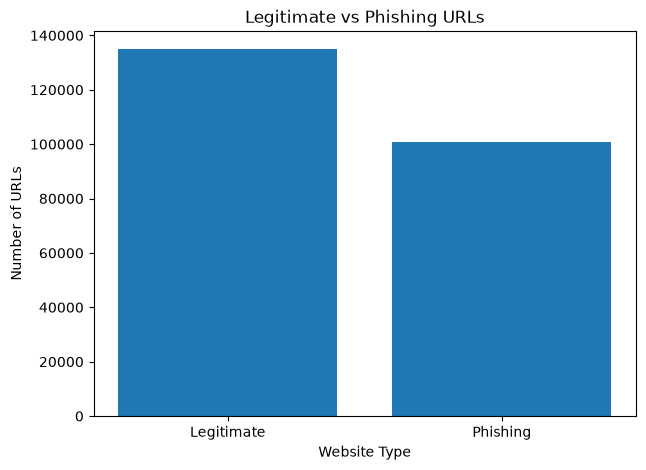

In [144]:
import matplotlib.pyplot as plt

label_counts = df["label"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Legitimate", "Phishing"],
    [
        label_counts.get(1, 0),
        label_counts.get(0, 0)
    ]
)

plt.title("Legitimate vs Phishing URLs")
plt.xlabel("Website Type")
plt.ylabel("Number of URLs")

plt.show()

In [145]:
df["URLLength"].describe()

count    235795.000000
mean         34.573095
std          41.314153
min          13.000000
25%          23.000000
50%          27.000000
75%          34.000000
max        6097.000000
Name: URLLength, dtype: float64

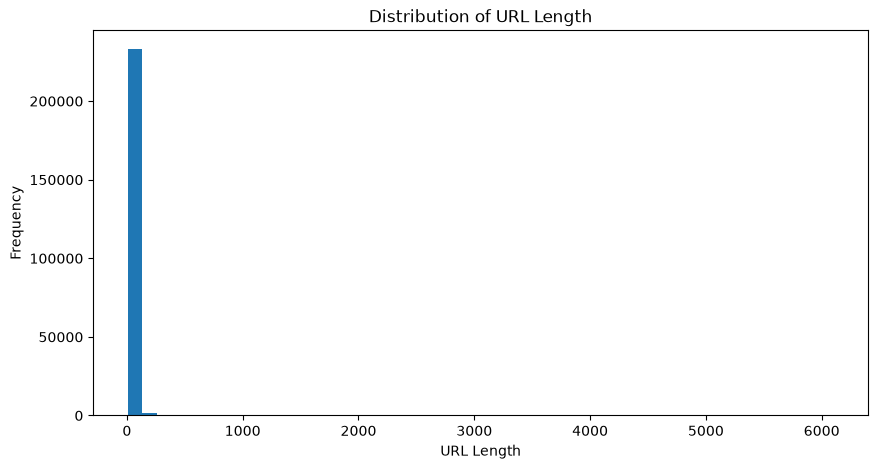

In [146]:
plt.figure(figsize=(10, 5))

plt.hist(df["URLLength"], bins=50)

plt.title("Distribution of URL Length")
plt.xlabel("URL Length")
plt.ylabel("Frequency")

plt.show()

In [147]:
df.groupby("label")["URLLength"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100945.0,45.720293,61.145523,13.0,26.0,34.0,48.0,6097.0
1,134850.0,26.228610,4.815612,15.0,23.0,26.0,29.0,57.0


<Figure size 800x500 with 0 Axes>

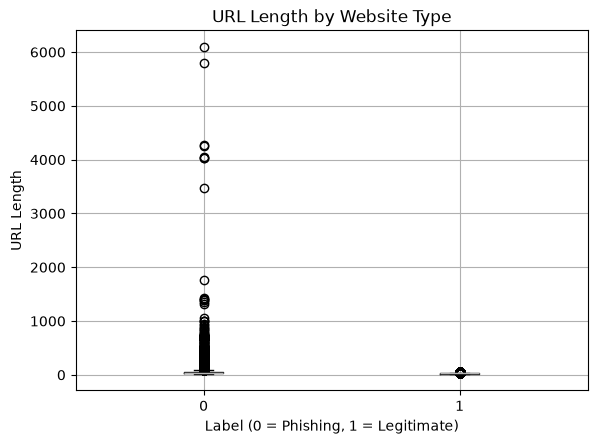

In [148]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="URLLength",
    by="label"
)

plt.title("URL Length by Website Type")
plt.suptitle("")

plt.xlabel("Label (0 = Phishing, 1 = Legitimate)")
plt.ylabel("URL Length")

plt.show()

In [149]:
pd.crosstab(
    df["IsHTTPS"],
    df["label"],
    normalize="index"
) * 100


label,0,1
IsHTTPS,,
0,100.000000,0.000000
1,26.926016,73.073984


In [150]:
pd.crosstab(
    df["IsHTTPS"],
    df["label"]
)

label,0,1
IsHTTPS,,
0,51256,0
1,49689,134850


In [151]:
pd.crosstab(
    df["IsDomainIP"],
    df["label"]
)

label,0,1
IsDomainIP,,
0,100307,134850
1,638,0


In [152]:
pd.crosstab(
    df["IsDomainIP"],
    df["label"],
    normalize="index"
) * 100

label,0,1
IsDomainIP,,
0,42.655332,57.344668
1,100.000000,0.000000


In [153]:
correlation = df[numeric_columns].corr()

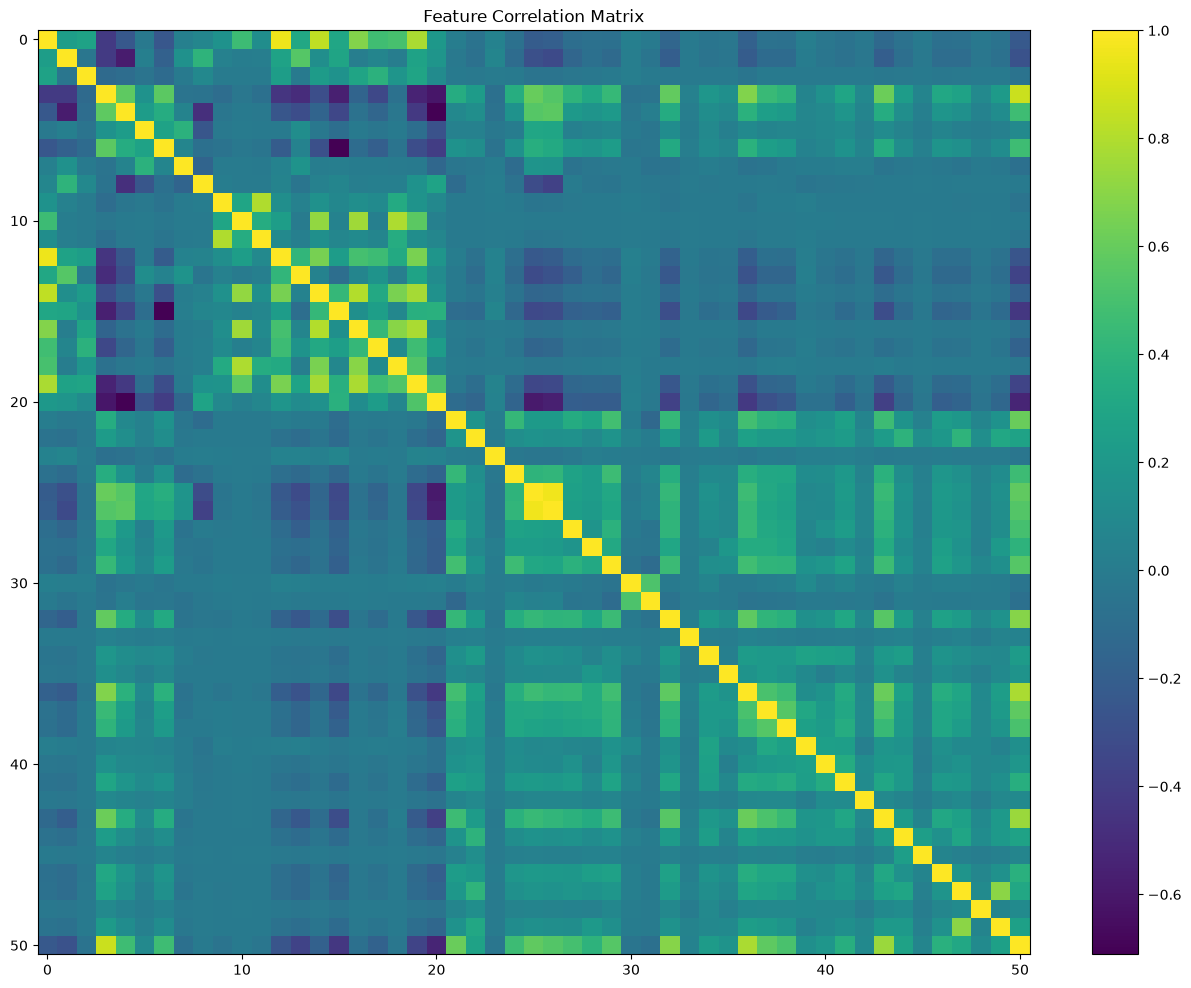

In [154]:
plt.figure(figsize=(16, 12))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.title("Feature Correlation Matrix")

plt.show()

In [155]:
https_distribution = pd.crosstab(
    df["IsHTTPS"],
    df["label"],
    normalize="index"
) * 100

https_distribution

label,0,1
IsHTTPS,,
0,100.000000,0.000000
1,26.926016,73.073984


In [156]:
categorical_columns

['FILENAME', 'URL', 'Domain', 'TLD', 'Title']

In [157]:
correlations = (
    df[numeric_columns]
    .corr()["label"]
    .drop("label")
    .sort_values(key=abs, ascending=False)
)

correlations.head(15)

URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL   -0.533537
HasHiddenFields          0.507731
HasFavicon               0.493711
URLCharProb              0.469749
CharContinuationRate     0.467735
HasTitle                 0.459725
Name: label, dtype: float64

In [158]:
df["FILENAME"].nunique()

235795

In [159]:
df["Domain"].nunique()

220086

In [160]:
df["TLD"].nunique()

695

In [161]:
df["Title"].nunique()

197874

In [162]:
df[["URL", "Domain", "TLD", "Title", "label"]].head(10)

,URL,Domain,TLD,Title,label
0,https://www.southbankmosaics.com,www.southbankmosaics.com,com,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,1
1,https://www.uni-mainz.de,www.uni-mainz.de,de,johannes gutenberg-universitÃ¤t mainz,1
2,https://www.voicefmradio.co.uk,www.voicefmradio.co.uk,uk,voice fm southampton,1
3,https://www.sfnmjournal.com,www.sfnmjournal.com,com,home page: seminars in fetal and neonatal medi...,1
4,https://www.rewildingargentina.org,www.rewildingargentina.org,org,fundaciÃ³n rewilding argentina,1
5,https://www.globalreporting.org,www.globalreporting.org,org,gri - home,1
6,https://www.saffronart.com,www.saffronart.com,com,0,1
7,https://www.nerdscandy.com,www.nerdscandy.com,com,nerds candy,1
8,https://www.hyderabadonline.in,www.hyderabadonline.in,in,hyderabadonline - business listing in hyderaba...,1
9,https://www.aap.org,www.aap.org,org,home,1


In [163]:
print("FILENAME:", df["FILENAME"].nunique())
print("Domain:", df["Domain"].nunique())
print("TLD:", df["TLD"].nunique())
print("Title:", df["Title"].nunique())

FILENAME: 235795
Domain: 220086
TLD: 695
Title: 197874


In [164]:
df[["URL", "Domain", "TLD", "Title", "label"]].head(10)

,URL,Domain,TLD,Title,label
0,https://www.southbankmosaics.com,www.southbankmosaics.com,com,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,1
1,https://www.uni-mainz.de,www.uni-mainz.de,de,johannes gutenberg-universitÃ¤t mainz,1
2,https://www.voicefmradio.co.uk,www.voicefmradio.co.uk,uk,voice fm southampton,1
3,https://www.sfnmjournal.com,www.sfnmjournal.com,com,home page: seminars in fetal and neonatal medi...,1
4,https://www.rewildingargentina.org,www.rewildingargentina.org,org,fundaciÃ³n rewilding argentina,1
5,https://www.globalreporting.org,www.globalreporting.org,org,gri - home,1
6,https://www.saffronart.com,www.saffronart.com,com,0,1
7,https://www.nerdscandy.com,www.nerdscandy.com,com,nerds candy,1
8,https://www.hyderabadonline.in,www.hyderabadonline.in,in,hyderabadonline - business listing in hyderaba...,1
9,https://www.aap.org,www.aap.org,org,home,1


In [165]:
print("FILENAME:", df["FILENAME"].nunique())
print("Domain:", df["Domain"].nunique())
print("TLD:", df["TLD"].nunique())
print("Title:", df["Title"].nunique())

FILENAME: 235795
Domain: 220086
TLD: 695
Title: 197874


In [166]:
df[["URL", "Domain", "TLD", "Title", "label"]].head(10)

,URL,Domain,TLD,Title,label
0,https://www.southbankmosaics.com,www.southbankmosaics.com,com,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,1
1,https://www.uni-mainz.de,www.uni-mainz.de,de,johannes gutenberg-universitÃ¤t mainz,1
2,https://www.voicefmradio.co.uk,www.voicefmradio.co.uk,uk,voice fm southampton,1
3,https://www.sfnmjournal.com,www.sfnmjournal.com,com,home page: seminars in fetal and neonatal medi...,1
4,https://www.rewildingargentina.org,www.rewildingargentina.org,org,fundaciÃ³n rewilding argentina,1
5,https://www.globalreporting.org,www.globalreporting.org,org,gri - home,1
6,https://www.saffronart.com,www.saffronart.com,com,0,1
7,https://www.nerdscandy.com,www.nerdscandy.com,com,nerds candy,1
8,https://www.hyderabadonline.in,www.hyderabadonline.in,in,hyderabadonline - business listing in hyderaba...,1
9,https://www.aap.org,www.aap.org,org,home,1


In [167]:
print("Before:", df.shape)

Before: (235795, 56)


In [168]:
df = df.drop_duplicates(subset="URL", keep="first")

In [169]:
print("After:", df.shape)

After: (235370, 56)


In [170]:
df = df.drop(columns=["FILENAME"])

In [171]:
print(df.shape)

(235370, 55)


In [172]:
df.info()

<class 'pandas.DataFrame'>
Index: 235370 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235370 non-null  str    
 1   URLLength                   235370 non-null  int64  
 2   Domain                      235370 non-null  str    
 3   DomainLength                235370 non-null  int64  
 4   IsDomainIP                  235370 non-null  int64  
 5   TLD                         235370 non-null  str    
 6   URLSimilarityIndex          235370 non-null  float64
 7   CharContinuationRate        235370 non-null  float64
 8   TLDLegitimateProb           235370 non-null  float64
 9   URLCharProb                 235370 non-null  float64
 10  TLDLength                   235370 non-null  int64  
 11  NoOfSubDomain               235370 non-null  int64  
 12  HasObfuscation              235370 non-null  int64  
 13  NoOfObfuscatedChar          23

In [173]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate URLs:", df["URL"].duplicated().sum())

Missing values:

 0
Duplicate URLs: 0


In [174]:
df["label"].value_counts()

label
1    134850
0    100520
Name: count, dtype: int64

In [175]:
y = df["label"]

In [176]:
X = df.drop(columns=["label"])

In [177]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (235370, 54)
y shape: (235370,)


In [178]:
for i, column in enumerate(X.columns, start=1):
    print(i, column)

1 URL
2 URLLength
3 Domain
4 DomainLength
5 IsDomainIP
6 TLD
7 URLSimilarityIndex
8 CharContinuationRate
9 TLDLegitimateProb
10 URLCharProb
11 TLDLength
12 NoOfSubDomain
13 HasObfuscation
14 NoOfObfuscatedChar
15 ObfuscationRatio
16 NoOfLettersInURL
17 LetterRatioInURL
18 NoOfDegitsInURL
19 DegitRatioInURL
20 NoOfEqualsInURL
21 NoOfQMarkInURL
22 NoOfAmpersandInURL
23 NoOfOtherSpecialCharsInURL
24 SpacialCharRatioInURL
25 IsHTTPS
26 LineOfCode
27 LargestLineLength
28 HasTitle
29 Title
30 DomainTitleMatchScore
31 URLTitleMatchScore
32 HasFavicon
33 Robots
34 IsResponsive
35 NoOfURLRedirect
36 NoOfSelfRedirect
37 HasDescription
38 NoOfPopup
39 NoOfiFrame
40 HasExternalFormSubmit
41 HasSocialNet
42 HasSubmitButton
43 HasHiddenFields
44 HasPasswordField
45 Bank
46 Pay
47 Crypto
48 HasCopyrightInfo
49 NoOfImage
50 NoOfCSS
51 NoOfJS
52 NoOfSelfRef
53 NoOfEmptyRef
54 NoOfExternalRef


In [179]:
X_baseline = X.drop(
    columns=["URL", "Domain", "Title", "TLD"]
)

In [180]:
print(X_baseline.shape)

(235370, 50)


In [181]:
print(X_baseline.dtypes.value_counts())

int64      40
float64    10
Name: count, dtype: int64


In [182]:
X_baseline.select_dtypes(exclude=np.number).columns.tolist()

[]

In [183]:
y = df["label"]

X = df.drop(columns=["label"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (235370, 54)
y shape: (235370,)


In [184]:
X_baseline = X.drop(
    columns=["URL", "Domain", "Title", "TLD"]
)

print("Baseline X shape:", X_baseline.shape)

Baseline X shape: (235370, 50)


In [185]:
print(X_baseline.dtypes.value_counts())
print("\nNon-numeric columns:")
print(X_baseline.select_dtypes(exclude=np.number).columns.tolist())

int64      40
float64    10
Name: count, dtype: int64

Non-numeric columns:
[]


In [186]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_baseline,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (188296, 50)
X_test : (47074, 50)
y_train: (188296,)
y_test : (47074,)


In [187]:
stratify=y

In [188]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64

Testing distribution:
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64


In [189]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


c:\Users\premk\Desktop\ML_Projects\malicious-website-detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [190]:
y_pred = logistic_model.predict(X_test)

In [191]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9997025959128181


In [192]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



In [193]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[20093    11]
 [    3 26967]]


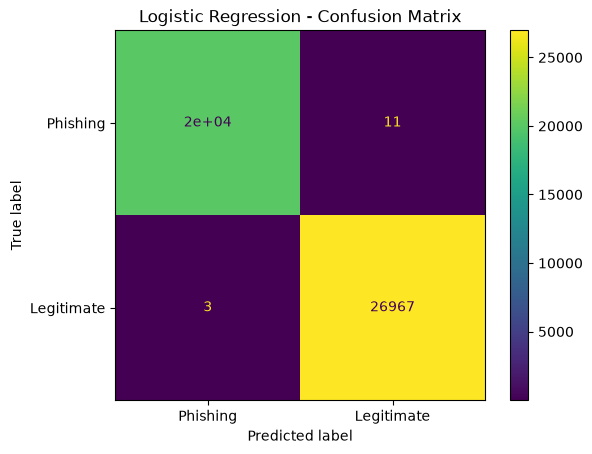

In [194]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Phishing", "Legitimate"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [195]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 20093
False Positives: 11
False Negatives: 3
True Positives  : 26967


In [196]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_phishing = precision_score(
    y_test,
    y_pred,
    pos_label=0
)

recall_phishing = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

f1_phishing = f1_score(
    y_test,
    y_pred,
    pos_label=0
)

print("Phishing Precision:", precision_phishing)
print("Phishing Recall   :", recall_phishing)
print("Phishing F1-score :", f1_phishing)

Phishing Precision: 0.9998507165605095
Phishing Recall   : 0.9994528452049344
Phishing F1-score : 0.9996517412935323


In [197]:
from sklearn.metrics import roc_auc_score

y_probability = logistic_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9999995038775747


In [198]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Phishing Precision": [precision_phishing],
    "Phishing Recall": [recall_phishing],
    "Phishing F1": [f1_phishing],
    "ROC-AUC": [roc_auc]
})

results

,Model,Accuracy,Phishing Precision,Phishing Recall,Phishing F1,ROC-AUC
0,Logistic Regression,0.999703,0.999851,0.999453,0.999652,1.0


In [199]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [200]:
rf_pred = rf_model.predict(X_test)

In [201]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



In [202]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [203]:
# Random Forest

In [204]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [205]:
rf_pred = rf_model.predict(X_test)

In [206]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



In [207]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [208]:
rf_precision = precision_score(
    y_test,
    rf_pred,
    pos_label=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    pos_label=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    pos_label=0
)

print("Phishing Precision:", rf_precision)
print("Phishing Recall:", rf_recall)
print("Phishing F1:", rf_f1)

Phishing Precision: 1.0
Phishing Recall: 1.0
Phishing F1: 1.0


In [209]:
# Compare the two models

In [210]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Phishing Precision": [
        precision_phishing,
        rf_precision
    ],
    "Phishing Recall": [
        recall_phishing,
        rf_recall
    ],
    "Phishing F1": [
        f1_phishing,
        rf_f1
    ]
})

comparison

,Model,Accuracy,Phishing Precision,Phishing Recall,Phishing F1
0,Logistic Regression,0.999703,0.999851,0.999453,0.999652
1,Random Forest,1.000000,1.000000,1.000000,1.000000


In [211]:
# Check Random Forest Confusion Matrix

In [212]:
cm_rf = confusion_matrix(y_test, rf_pred)

print(cm_rf)

[[20104     0]
 [    0 26970]]


In [213]:
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print("True Negatives :", tn_rf)
print("False Positives:", fp_rf)
print("False Negatives:", fn_rf)
print("True Positives  :", tp_rf)

True Negatives : 20104
False Positives: 0
False Negatives: 0
True Positives  : 26970


In [214]:
# Find Random Forest Feature Importance

In [215]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_baseline.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance.head(15)

URLSimilarityIndex            0.206271
NoOfExternalRef               0.167875
LineOfCode                    0.132689
NoOfImage                     0.112352
NoOfSelfRef                   0.085843
NoOfJS                        0.074270
HasSocialNet                  0.033937
NoOfCSS                       0.029536
HasDescription                0.023344
HasCopyrightInfo              0.021131
IsHTTPS                       0.015398
NoOfOtherSpecialCharsInURL    0.013966
LargestLineLength             0.012975
NoOfDegitsInURL               0.010841
URLLength                     0.007513
dtype: float64

In [216]:
# Visualize the Top 15 Features

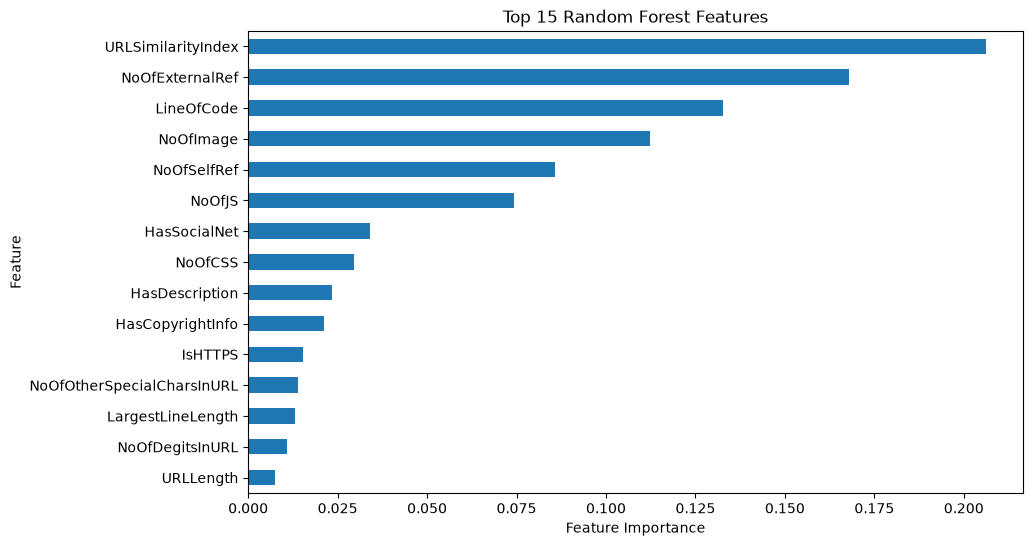

In [217]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Random Forest Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [218]:
# The Important Investigation

In [219]:
feature_importance.head(10)

URLSimilarityIndex    0.206271
NoOfExternalRef       0.167875
LineOfCode            0.132689
NoOfImage             0.112352
NoOfSelfRef           0.085843
NoOfJS                0.074270
HasSocialNet          0.033937
NoOfCSS               0.029536
HasDescription        0.023344
HasCopyrightInfo      0.021131
dtype: float64

In [220]:
# nvestigate the perfect separation

In [221]:
df.groupby("label")[
    [
        "URLSimilarityIndex",
        "NoOfExternalRef",
        "LineOfCode",
        "NoOfImage",
        "NoOfSelfRef",
        "NoOfJS",
        "NoOfCSS"
    ]
].mean()


,URLSimilarityIndex,NoOfExternalRef,LineOfCode,NoOfImage,NoOfSelfRef,NoOfJS,NoOfCSS
label,,,,,,,
0,49.651466,1.126960,65.606257,0.864206,0.496180,0.887992,0.43844
1,100.000000,85.294601,1947.491680,44.946600,113.410241,17.732532,10.74482


In [222]:
# Check the ranges

In [223]:
df.groupby("label")[
    [
        "URLSimilarityIndex",
        "NoOfExternalRef",
        "LineOfCode",
        "NoOfImage",
        "NoOfSelfRef",
        "NoOfJS",
        "NoOfCSS"
    ]
].agg(["mean", "median", "min", "max"])

URLSimilarityIndex                                NoOfExternalRef  \
                    mean      median         min    max            mean   
label                                                                     
0              49.651466   51.478561    0.155574  100.0        1.126960   
1             100.000000  100.000000  100.000000  100.0       85.294601   

                          LineOfCode          ... NoOfSelfRef         \
      median min    max         mean  median  ...         min    max   
label                                         ...                      
0        0.0   0    368    65.606257    12.0  ...           0    120   
1       46.0   0  27516  1947.491680  1105.0  ...           0  27397   

          NoOfJS                    NoOfCSS                    
            mean median min   max      mean median min    max  
label                                                          
0       0.887992    0.0   0   102   0.43844    0.0   0    131  
1      17.732532   14.0   0  6957  10.74482    6.0   0  35820  

[2 rows x 28 columns]

In [224]:
# Check feature distributions visually

<Figure size 1000x500 with 0 Axes>

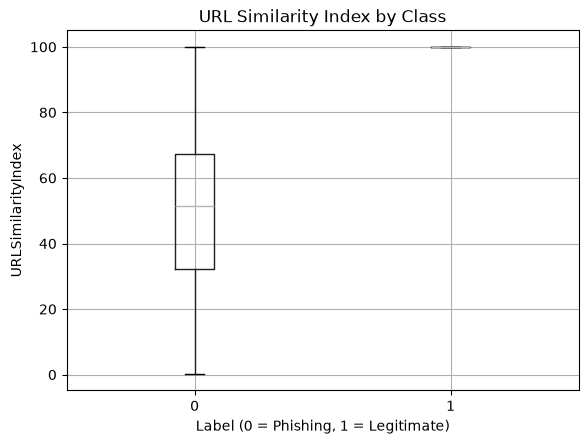

In [225]:
plt.figure(figsize=(10, 5))

df.boxplot(
    column="URLSimilarityIndex",
    by="label"
)

plt.title("URL Similarity Index by Class")
plt.suptitle("")

plt.xlabel("Label (0 = Phishing, 1 = Legitimate)")
plt.ylabel("URLSimilarityIndex")

plt.show()

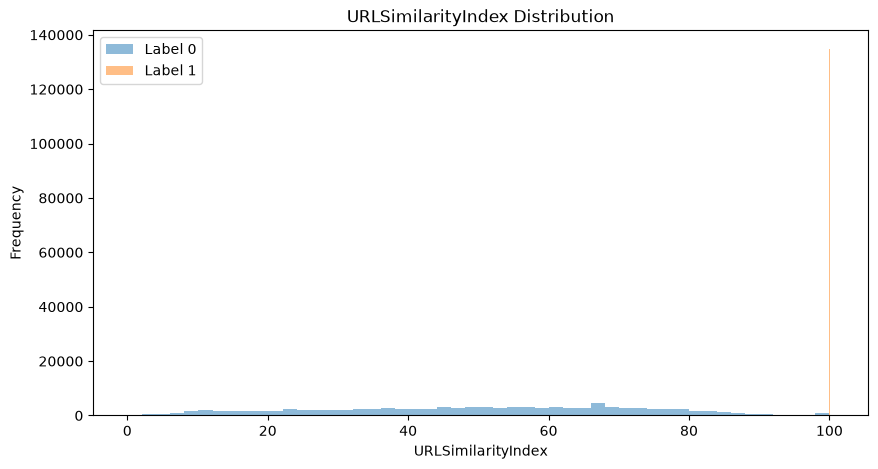

In [226]:
plt.figure(figsize=(10, 5))

for label in [0, 1]:
    plt.hist(
        df[df["label"] == label]["URLSimilarityIndex"],
        bins=50,
        alpha=0.5,
        label=f"Label {label}"
    )

plt.title("URLSimilarityIndex Distribution")
plt.xlabel("URLSimilarityIndex")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [227]:
# Check for duplicate rows beyond URLs

In [228]:
print(
    "Duplicate complete rows:",
    df.duplicated().sum()
)

Duplicate complete rows: 0


In [229]:
#Check Complete Duplicate Rows

In [230]:
print("Duplicate complete rows:", df.duplicated().sum())

Duplicate complete rows: 0


In [231]:
#Check URLSimilarityIndex directly

In [232]:
print(
    df.groupby("label")["URLSimilarityIndex"]
    .value_counts()
    .head(20)
)

label  URLSimilarityIndex
0      100.000000            786
       66.720000             743
       66.695385             489
       36.681914             488
       22.334010             369
       49.385610             363
       60.845588             237
       80.000000             219
       9.540762              216
       23.030879             201
       77.283951             182
       54.301391             181
       55.299247             180
       23.947855             177
       32.120613             174
       20.448987             168
       82.093664             154
       66.666667             148
       19.126157             145
       69.454545             141
Name: count, dtype: int64


In [233]:
print(
    "Legitimate URLs with URLSimilarityIndex = 100:",
    ((df["label"] == 1) & 
     (df["URLSimilarityIndex"] == 100)).sum()
)

Legitimate URLs with URLSimilarityIndex = 100: 134850


In [234]:
# Our next decision

In [236]:
# Experiment A — Full dataset features

In [235]:
"""     50 numerical features
              ↓
        Logistic Regression
                ↓
        Random Forest           """

'     50 numerical features\n              ↓\n        Logistic Regression\n                ↓\n        Random Forest           '

In [237]:
# Experiment B

# Remove these seven highly informative webpage features:

In [238]:
# Create the reduced feature set

In [239]:
features_to_remove = [
    "URLSimilarityIndex",
    "NoOfExternalRef",
    "LineOfCode",
    "NoOfImage",
    "NoOfSelfRef",
    "NoOfJS",
    "NoOfCSS"
]

X_reduced = X_baseline.drop(columns=features_to_remove)

print("Original features:", X_baseline.shape[1])
print("Reduced features:", X_reduced.shape[1])

Original features: 50
Reduced features: 43


In [240]:
# Split the reduced dataset

In [241]:
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train_red.shape)
print("Testing :", X_test_red.shape)

Training: (188296, 43)
Testing : (47074, 43)


In [242]:
# Train Random Forest again

In [243]:
rf_reduced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_reduced.fit(X_train_red, y_train_red)

print("Reduced-feature Random Forest trained!")

Reduced-feature Random Forest trained!


In [244]:
# Predict

In [246]:
rf_reduced_pred = rf_reduced.predict(X_test_red)

In [247]:
# Evaluate

In [248]:
print(classification_report(
    y_test_red,
    rf_reduced_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



In [249]:
reduced_accuracy = accuracy_score(
    y_test_red,
    rf_reduced_pred
)

reduced_precision = precision_score(
    y_test_red,
    rf_reduced_pred,
    pos_label=0
)

reduced_recall = recall_score(
    y_test_red,
    rf_reduced_pred,
    pos_label=0
)

reduced_f1 = f1_score(
    y_test_red,
    rf_reduced_pred,
    pos_label=0
)

print("Accuracy:", reduced_accuracy)
print("Phishing Precision:", reduced_precision)
print("Phishing Recall:", reduced_recall)
print("Phishing F1:", reduced_f1)

Accuracy: 0.9995114075710584
Phishing Precision: 0.9997511323478174
Phishing Recall: 0.9991046557898926
Phishing F1: 0.9994277895260605


In [250]:
# Use 5-Fold Cross-Validation

In [251]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(
    rf_cv,
    X_reduced,
    y,
    cv=cv,
    scoring="f1"
)

print("Cross-validation F1 scores:")
print(cv_scores)

print("\nMean F1:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation F1 scores:
[0.99946242 0.99936972 0.99944391 0.99951811 0.9996478 ]

Mean F1: 0.9994883903213004
Standard deviation: 9.277077281340803e-05


In [252]:
# Hyperparameter Tuning,

In [253]:
n_estimators=200

In [254]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [256]:
# GridSearchCV

In [257]:
from sklearn.model_selection import GridSearchCV

In [258]:
GridSearchCV

sklearn.model_selection._search.GridSearchCV

In [259]:
# Create GridSearchCV

In [260]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

In [261]:
grid_search.fit(X_reduced, y)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model

In [262]:
# Find the best parameters 

In [263]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [264]:
print("Best cross-validation F1:")
print(grid_search.best_score_)

Best cross-validation F1:
0.9994513363872444


In [265]:
 # Get the best model

In [266]:
best_rf = grid_search.best_estimator_

print(best_rf)

RandomForestClassifier(max_depth=20, n_estimators=200, n_jobs=-1,
                       random_state=42)


In [267]:
{
    'max_depth': 20,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 200
}

{'max_depth': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [268]:
# Evaluate the Tuned Model on the Test Set

In [269]:
best_rf_pred = best_rf.predict(X_test_red)

In [270]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_accuracy = accuracy_score(
    y_test_red,
    best_rf_pred
)

best_precision = precision_score(
    y_test_red,
    best_rf_pred,
    pos_label=0
)

best_recall = recall_score(
    y_test_red,
    best_rf_pred,
    pos_label=0
)

best_f1 = f1_score(
    y_test_red,
    best_rf_pred,
    pos_label=0
)

print("Accuracy:", best_accuracy)
print("Phishing Precision:", best_precision)
print("Phishing Recall:", best_recall)
print("Phishing F1:", best_f1)

Accuracy: 0.9999150274036623
Phishing Precision: 1.0
Phishing Recall: 0.9998010346199762
Phishing F1: 0.9999005074121978


In [271]:
print(classification_report(
    y_test_red,
    best_rf_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



In [272]:
# Final Tuned Confusion Matrix

In [273]:
cm_best = confusion_matrix(
    y_test_red,
    best_rf_pred
)

print(cm_best)

[[20100     4]
 [    0 26970]]


In [276]:
tn, fp, fn, tp = cm_best.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 20100
False Positives: 4
False Negatives: 0
True Positives  : 26970
